<a href="https://colab.research.google.com/github/MrChooey/Diabetes_Readmission/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc, average_precision_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TF version:", tf.__version__)

TF version: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# === CONFIG ===
PATH_TO_TRAIN_CSV = "/content/drive/MyDrive/diabetes_readmission/Dataset/training.csv"
TARGET_COL = "readmitted"

df = pd.read_csv(PATH_TO_TRAIN_CSV)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

feature_names = X.columns.tolist()
print("Train shape:", df.shape)
print("Pos class ratio:", y.mean().round(4))

Mounted at /content/drive
Train shape: (71219, 105)
Pos class ratio: 0.1116


In [ ]:
def build_dnn(input_dim: int) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

def summarize_fold(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return dict(
        accuracy = accuracy_score(y_true, y_pred),
        precision= precision_score(y_true, y_pred, zero_division=0),
        recall   = recall_score(y_true, y_pred, zero_division=0),
        f1       = f1_score(y_true, y_pred, zero_division=0),
        auc_roc  = roc_auc_score(y_true, y_prob)
    )

In [ ]:
N_SPLITS = 5
BATCH_SIZE = 512
EPOCHS = 60
PATIENCE = 8

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba = np.zeros(len(X), dtype=np.float32)
oof_pred  = np.zeros(len(X), dtype=np.int32)
fold_metrics = []

print("Beginning 5-fold CV for DNN...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx].values
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx].values

    # Apply SMOTE to training folds
    smote = SMOTE(random_state=SEED)
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    scaler = StandardScaler()
    X_tr_res = scaler.fit_transform(X_tr_res)
    X_va_sc  = scaler.transform(X_va)

    model = build_dnn(input_dim=X_tr_res.shape[1])
    cb = [
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                      patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                          factor=0.5, patience=max(PATIENCE//2, 2), min_lr=1e-5, verbose=0)
    ]

    history = model.fit(
        X_tr_res.astype("float32"), y_tr_res.astype("float32"),
        validation_data=(X_va_sc.astype("float32"), y_va.astype("float32")),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, callbacks=cb
    )

    va_prob = model.predict(X_va_sc, verbose=0).ravel()
    va_pred = (va_prob >= 0.5).astype(int)

    oof_proba[va_idx] = va_prob
    oof_pred[va_idx]  = va_pred

    m = summarize_fold(y_va, va_prob, thr=0.5)
    fold_metrics.append({"fold": fold, **m})
    print(f"Fold {fold}: Acc={m['accuracy']:.4f} | Pre={m['precision']:.4f} | "
          f"Rec={m['recall']:.4f} | F1={m['f1']:.4f} | AUC={m['auc_roc']:.4f}")

print("\nDone.")

Beginning 5-fold CV for DNN...
Fold 1: Acc=0.8868 | Pre=0.3380 | Rec=0.0151 | F1=0.0289 | AUC=0.6687
Fold 2: Acc=0.8873 | Pre=0.3621 | Rec=0.0132 | F1=0.0255 | AUC=0.6676
Fold 3: Acc=0.8869 | Pre=0.3854 | Rec=0.0233 | F1=0.0439 | AUC=0.6535
Fold 4: Acc=0.8870 | Pre=0.3956 | Rec=0.0226 | F1=0.0428 | AUC=0.6687
Fold 5: Acc=0.8873 | Pre=0.4111 | Rec=0.0233 | F1=0.0441 | AUC=0.6537

Done.


In [ ]:
metrics_df = pd.DataFrame(fold_metrics)
display(metrics_df)

avg = metrics_df[["accuracy","precision","recall","f1","auc_roc"]].mean()
std = metrics_df[["accuracy","precision","recall","f1","auc_roc"]].std()

print("\n=== Averaged 5-Fold Performance (DNN) ===")
for k in ["accuracy","precision","recall","f1","auc_roc"]:
    print(f"{k.upper():9s}: {avg[k]:.4f} ± {std[k]:.4f}")

level1_dnn = pd.DataFrame({
    "dnn_oof_proba": oof_proba,
    "dnn_oof_pred":  oof_pred
}, index=X.index)

display(level1_dnn.head())

SAVE_OOF = "/content/drive/MyDrive/diabetes_readmission/Results/level1_oof_train_dnn.csv"
level1_dnn.to_csv(SAVE_OOF, index=True)
print("Saved DNN OOF features to:", SAVE_OOF)

,fold,accuracy,precision,recall,f1,auc_roc
0,1,0.886830,0.338028,0.015104,0.028916,0.668664
1,2,0.887321,0.362069,0.013216,0.025501,0.667566
2,3,0.886900,0.385417,0.023285,0.043917,0.653513
3,4,0.887040,0.395604,0.022642,0.042832,0.668750
4,5,0.887313,0.411111,0.023285,0.044074,0.653717



=== Averaged 5-Fold Performance (DNN) ===
ACCURACY : 0.8871 ± 0.0002
PRECISION: 0.3784 ± 0.0288
RECALL   : 0.0195 ± 0.0049
F1       : 0.0370 ± 0.0091
AUC_ROC  : 0.6624 ± 0.0081


,dnn_oof_proba,dnn_oof_pred
0,0.053456,0
1,0.208160,0
2,0.188429,0
3,0.114412,0
4,0.265355,0


Saved DNN OOF features to: /content/drive/MyDrive/diabetes_readmission/Results/level1_oof_train_dnn.csv


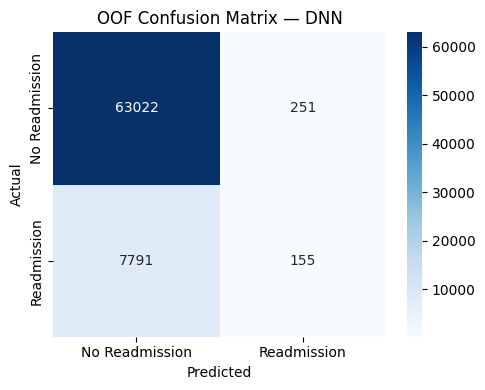

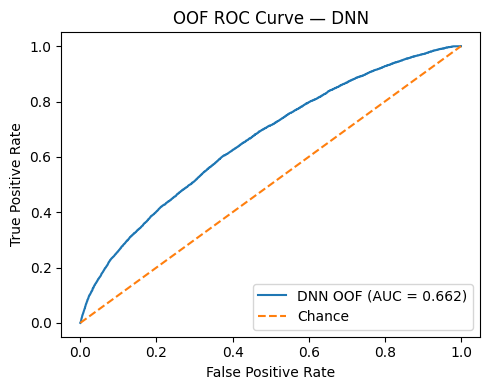

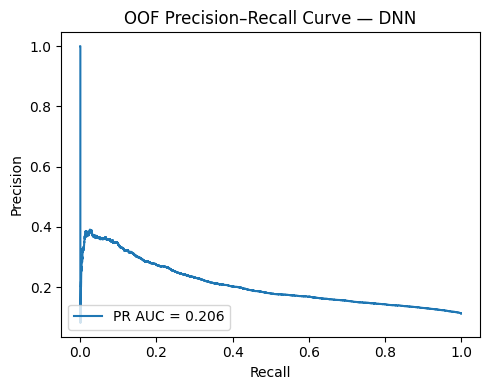

In [ ]:
# Confusion Matrix (OOF)
cm = confusion_matrix(y, oof_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Readmission","Readmission"],
            yticklabels=["No Readmission","Readmission"])
plt.title("OOF Confusion Matrix — DNN")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# ROC Curve (OOF)
fpr, tpr, _ = roc_curve(y, oof_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"DNN OOF (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("OOF ROC Curve — DNN")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

# Precision-Recall Curve (OOF)
precision, recall, _ = precision_recall_curve(y, oof_proba)
pr_auc = average_precision_score(y, oof_proba)
plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("OOF Precision–Recall Curve — DNN")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()
